# Projeto de Machine Learning - Algoritmo KNN

In [46]:
# Importação das bibliotecas utilizadas na atividade
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

In [2]:
# Leitura do dataset no dataframe
df = pd.read_csv('data/heart.csv')

## 1. Análise Exploratória dos dados

In [3]:
# Quantas linhas e colunas o dataset possui
df.shape

(1025, 14)

In [4]:
# Exibir as 5 primeiras linhas do dataset
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


#### Sobre o Dataset
O dataset utilizado é o **Heart Disease Dataset**, que contém informações clínicas de pacientes para predizer a presença de doença cardíaca.

#### Informações de atributos do dataset
| Atributo | Descrição | Tipo |
|----------|-----------|------|

- **age** → idade da pessoa | Numérico Contínuo
- **sex** → sexo *(1 = homem, 0 = mulher)* | Categórico Binário
- **cp** → tipo de dor no peito *(4 categorias)* | Categórico Nominal
- **trestbps** → pressão arterial em repouso *(mmHg)* | Numérico Contínuo
- **chol** → nível de colesterol *(mg/dl)* | Numérico Contínuo
- **fbs** → glicemia alta em jejum *(1 = sim, 0 = não)* | Categórico Binário 
- **restecg** → resultado do eletrocardiograma *(0, 1, 2)* | Categórico Nominal
- **thalach** → frequência cardíaca máxima atingida | Numérico Contínuo
- **exang** → angina induzida por exercício *(1 = sim, 0 = não)* | Categórico Binário
- **oldpeak** → alteração cardíaca causada por esforço | Numérico Contínuo
- **slope** → inclinação dessa alteração durante exercício | Categórico Ordinal
- **ca** → número de vasos sanguíneos afetados *(0–3)* | Numérico Discreto
- **thal** → tipo de problema cardíaco *(0 = normal, 1 = fixo, 2 = reversível)* | Categórico Nominal

### 1.1 Tratamento de Dados

#### 1.1.1 Elementos Nulos

Não foram encontrados valores ausentes **(NaN)** no *dataset*. Portanto, não será necessário utilizar média, mediana ou moda para substituir valores faltantes (imputação).

In [5]:
# Identificar a quantidade de elementos nulos por coluna
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


#### 1.1.2 Elementos duplicados

Identifiquei que o *dataset* contém registros duplicados que distorcem as estatísticas descritivas. Removi essas duplicatas para garantir que o aprendizado de máquina aprenda padrões reais e não apenas repetições de uma amostra.

In [6]:
# Identificar a quantidade de duplicatas por coluna
df.duplicated().sum()

np.int64(723)

In [7]:
# Exibir amostra duplicada
df[df.duplicated()]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
15,34,0,1,118,210,0,1,192,0,0.7,2,0,2,1
31,50,0,1,120,244,0,1,162,0,1.1,2,0,2,1
43,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
55,55,1,0,140,217,0,1,111,1,5.6,0,0,3,0
61,66,0,2,146,278,0,0,152,0,0.0,1,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [8]:
# Remover elementos duplicados e criar uma nova variável limpa chamada: df_clean
df_clean = df.drop_duplicates()
df_clean

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0


### 1.2 Visualização dos Dados

#### 1.2.1 Estatísticas Descritivas Gerais

Após a etapa de limpeza, onde removemos os dados artificialmente duplicados, o conjunto de dados foi reduzido para **302 registros únicos**.

Abaixo, verifiquei as informações gerais e as estatísticas descritivas do *dataframe* limpo:

In [9]:
print("Informações Gerais do dataframe limpo")
df_clean.info()

Informações Gerais do dataframe limpo
<class 'pandas.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


In [10]:
print("Estatísticas Gerais do dataframe limpo")
df_clean.describe()

Estatísticas Gerais do dataframe limpo


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [11]:
print("Número de aparições do atributo 'target'")
print(df_clean['target'].value_counts())

print("============================================")

print("Porcentagem de aparições do atributo 'target'")
print(df_clean['target'].value_counts(normalize=True) * 100)

Número de aparições do atributo 'target'
target
1    164
0    138
Name: count, dtype: int64
Porcentagem de aparições do atributo 'target'
target
1    54.304636
0    45.695364
Name: proportion, dtype: float64


#### 1.2.2 Detecção e Análise de Outliers

Para comprender a distribuição das variáveis númericas e identificar possíveis valores atípicos, foi utilizado visualizações em **Boxplot** e o método matemático do **Intervalo Interquartil**.

Ao executar a detecção, o algoritmo sinalizou uma quantidade considerável de **outliers** em 7 atributos. No entanto, ao analisarmos os valores máximos e mínimos dessas colunas, podemos constar que **todos estão dentro do contexto médico**.

Sendo assim, esses **outliers** não são erros de digitação, ruídos ou anomalias. Portanto decidi não remover nenhum desses **outliers** para que o aprendizado de máquina entenda que é possível haver cenários extremos.

Detecção de Outliers


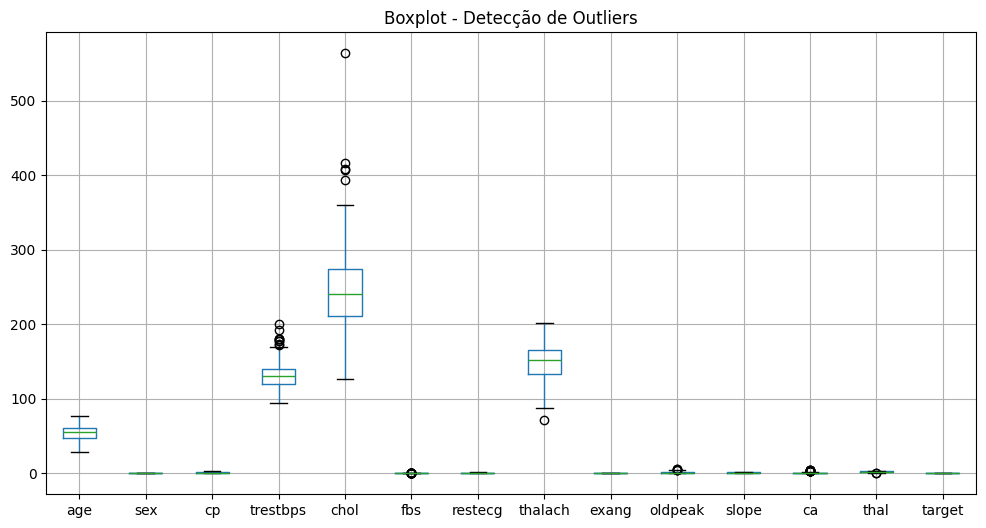

In [12]:
print("Detecção de Outliers")
df_clean.boxplot(figsize=(12,6))
plt.title("Boxplot - Detecção de Outliers")
plt.show()

In [13]:
# Bloco de código responsável por verificar o número de outliers presentes em cada coluna
Q1 = df_clean.quantile(0.25)
Q3 = df_clean.quantile(0.75)
IQR = Q3 - Q1

for col in df_clean.columns:
    outliers_col = df_clean[(df_clean[col] < (Q1[col] - 1.5 * IQR[col])) |
                            (df_clean[col] > (Q3[col] + 1.5 * IQR[col]))]
    
    print(f"{col}: {len(outliers_col)} outliers")

age: 0 outliers
sex: 0 outliers
cp: 0 outliers
trestbps: 9 outliers
chol: 5 outliers
fbs: 45 outliers
restecg: 0 outliers
thalach: 1 outliers
exang: 0 outliers
oldpeak: 5 outliers
slope: 0 outliers
ca: 24 outliers
thal: 2 outliers
target: 0 outliers


In [14]:
# Quantidade de outliers e valores mínimos e máximos presentes em cada coluna
for col in df_clean.columns:
    outliers_col = df_clean[
        (df_clean[col] < (Q1[col] - 1.5 * IQR[col])) |
        (df_clean[col] > (Q3[col] + 1.5 * IQR[col]))
    ]
    
    if len(outliers_col) > 0:
        print(f"\n=== {col} ===")
        print(f"Quantidade de outliers: {len(outliers_col)}")
        print("Mínimo:", df_clean[col].min())
        print("Máximo:", df_clean[col].max())


=== trestbps ===
Quantidade de outliers: 9
Mínimo: 94
Máximo: 200

=== chol ===
Quantidade de outliers: 5
Mínimo: 126
Máximo: 564

=== fbs ===
Quantidade de outliers: 45
Mínimo: 0
Máximo: 1

=== thalach ===
Quantidade de outliers: 1
Mínimo: 71
Máximo: 202

=== oldpeak ===
Quantidade de outliers: 5
Mínimo: 0.0
Máximo: 6.2

=== ca ===
Quantidade de outliers: 24
Mínimo: 0
Máximo: 4

=== thal ===
Quantidade de outliers: 2
Mínimo: 0
Máximo: 3


### 1.3 Conclusão da Análise Exploratória de Dados

- Não foram encontrados valores ausentes (NaN) no dataset;

- Foram identificados 723 registros duplicados, que foram removidos;

- Os outliers identificados fazem sentido clínico e por isso foram mantidos;

- O atributo 'target' presente no dataset está relativamente balanceado (54% / 46%).

## 2. Pré-Processamento de Dados

### 2.1 Codificação de Variáveis Categóricas (One-Hot Enconding)

O KNN calcula distâncias entre números. Se usarmos categorias como números (ex: 0, 1, 2), ele pode achar que existe uma ordem ou diferença maior entre elas. O **One-Hot Encoding** resolve isso transformando cada categoria em colunas de 0 ou 1, evitando interpretações erradas.

In [15]:
# Aplicação da técnica One-Hot Enconding em atributos categóricos
df_process = df_clean.copy()

vars_categoricos = ['cp', 'restecg', 'thal']
df_process = pd.get_dummies(df_process, columns=vars_categoricos, drop_first=False)

### 2.2 Divisão Treino/Teste

Essa etapa consiste em dividir o dataset em 80% treino (241 amostras) / 20% teste (61 amostras).

Essa divisão estratificada garante que a proporção das classes (doentes/saudáveis) seja mantida tanto no treino quanto no teste.

OBS: Durante o processo de desenvolvimento descobri que a Divisão Treino/Teste deve ser feita antes da normalização dos dados **(MinMaxScaler)**. Para evitar o vazamento de dados para o aprendizado de máquina.

In [16]:
# Identificação das colunas númericas do dataset
colunas_numericas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

# Separando os dados
X = df_process.drop('target', axis=1)
y = df_process['target']

# Dividindo o dataset em 80% treino / 20% teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Total: {len(X)}")
print(f"Treino: {len(X_treino)}")
print(f"Teste: {len(X_teste)}")


Total: 302
Treino: 241
Teste: 61


### 2.3 Normalização dos Dados (MinMaxScaler)

O KNN calcula distâncias entre pontos. Sem normalização, atributos com escalas maiores (ex: colesterol: 126-564 mg/dl) dominariam o cálculo em detrimento de atributos com escalas menores (ex: idade: 29-77 anos).

In [17]:
# Copiando o dataset original
X_treino = X_treino.copy()
X_teste = X_teste.copy()

# Aplicando a normalização
scaler = MinMaxScaler()

# Aplica a normalização nas colunas numéricas do conjunto de treino
X_treino[colunas_numericas] = scaler.fit_transform(X_treino[colunas_numericas])

# Aplica a mesma transformação no conjunto de teste
X_teste[colunas_numericas] = scaler.transform(X_teste[colunas_numericas])

### 2.4 Resultados esperados

No final da etapa de Pré-Processamento é esperado que se tenha a divisão entre o dataset utilizado nos treinos e testes do atributo target. É importante também que todos os atributos numéricos sejam normalizados, ou seja, valores de 0 a 1 com o objetivo de padronizar a magnitude dos dados. Além disso, os atributos categóricos devem ser codificados em números binários para não possuirem ordem.

In [18]:
# Resultado esperado: X com várias colunas e y com apenas 1 coluna (coluna target)
print(X.shape)
print(y.shape)

(302, 21)
(302,)


In [19]:
# Checar se 'target' saiu de X
print('target' in X.columns)

False


In [20]:
# Dataset final! Normalizado e com o One-Hot Encoding
X_treino

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,...,cp_1,cp_2,cp_3,restecg_0,restecg_1,restecg_2,thal_0,thal_1,thal_2,thal_3
158,0.791667,0,0.214286,1.000000,0,0.679389,0,0.258065,1,0.00,...,False,True,False,True,False,False,False,False,False,True
199,0.437500,1,0.510204,0.168950,0,0.419847,1,0.145161,1,0.00,...,False,False,False,True,False,False,False,False,False,True
479,0.604167,1,0.346939,0.205479,0,0.458015,1,0.354839,1,0.75,...,False,False,False,True,False,False,False,False,False,True
460,0.833333,1,0.469388,0.292237,0,0.572519,0,0.322581,1,0.75,...,False,True,False,True,False,False,False,False,False,True
169,0.333333,0,0.183673,0.077626,0,0.511450,0,0.000000,1,0.00,...,True,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,0.291667,0,0.285714,0.198630,0,0.717557,0,0.032258,1,0.00,...,False,True,False,False,True,False,False,False,True,False
320,0.500000,0,0.367347,0.315068,0,0.549618,0,0.064516,1,0.00,...,False,False,False,True,False,False,False,False,True,False
472,0.604167,0,0.367347,0.162100,0,0.458015,0,0.096774,1,0.00,...,False,False,False,False,True,False,False,False,True,False
733,0.312500,0,0.142857,0.034247,0,0.793893,0,0.096774,1,0.00,...,False,True,False,False,True,False,False,False,True,False


## 3. Implementação e Experimentação

In [21]:
k_valores = range(1,16)
metricas = {
    "euclidean": [],
    "manhattan": [],
    "chebyshev": [],
    "minkowski_p3": []
}

for k in k_valores:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_treino, y_treino)
    metricas['euclidean'].append(accuracy_score(y_teste, knn.predict(X_teste)))

    knn = KNeighborsClassifier(n_neighbors=k, metric='manhattan')
    knn.fit(X_treino, y_treino)
    metricas['manhattan'].append(accuracy_score(y_teste, knn.predict(X_teste)))

    knn = KNeighborsClassifier(n_neighbors=k, metric='chebyshev')
    knn.fit(X_treino, y_treino)
    metricas['chebyshev'].append(accuracy_score(y_teste, knn.predict(X_teste)))

    knn = KNeighborsClassifier(n_neighbors=k, metric="minkowski", p=3)
    knn.fit(X_treino, y_treino)
    metricas['minkowski_p3'].append(accuracy_score(y_teste, knn.predict(X_teste)))

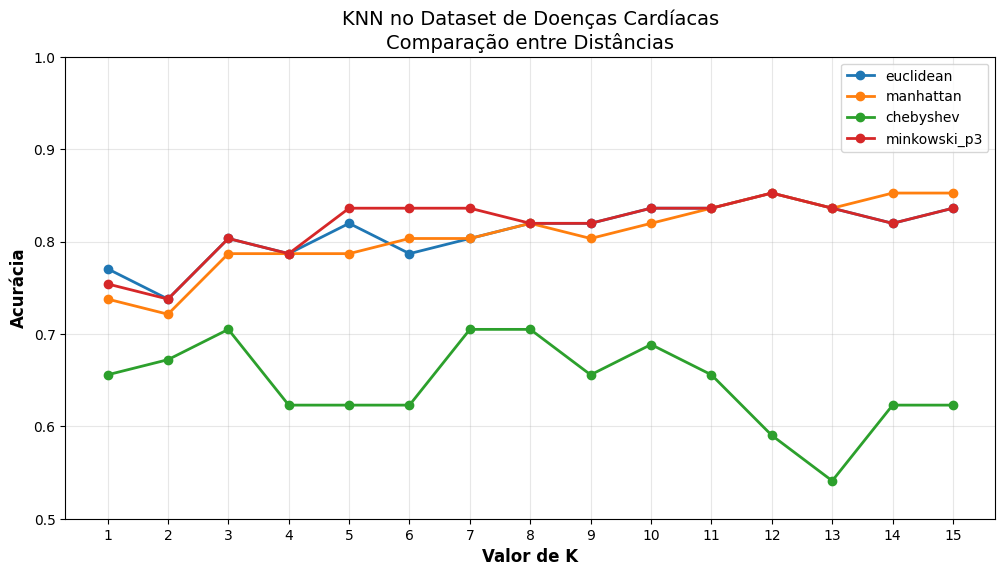

<Figure size 1200x600 with 0 Axes>

In [22]:
plt.figure(figsize=(12, 6))
for distancia, acuracias in metricas.items():
    plt.plot(k_valores, acuracias, marker='o', linewidth=2, label=distancia)
    
plt.xlabel('Valor de K', fontsize=12, fontweight='bold')
plt.ylabel('Acurácia', fontsize=12, fontweight='bold')
plt.title('KNN no Dataset de Doenças Cardíacas\nComparação entre Distâncias', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(k_valores)
plt.ylim(0.5, 1.0)
plt.figure(figsize=(12, 6))
plt.show()

In [23]:
df_resultados = pd.DataFrame(metricas, index=k_valores)

display(df_resultados * 100)

,euclidean,manhattan,chebyshev,minkowski_p3
1,77.049180,73.770492,65.573770,75.409836
2,73.770492,72.131148,67.213115,73.770492
3,80.327869,78.688525,70.491803,80.327869
4,78.688525,78.688525,62.295082,78.688525
5,81.967213,78.688525,62.295082,83.606557
6,78.688525,80.327869,62.295082,83.606557
7,80.327869,80.327869,70.491803,83.606557
8,81.967213,81.967213,70.491803,81.967213
9,81.967213,80.327869,65.573770,81.967213
10,83.606557,81.967213,68.852459,83.606557


## 4. Conclusão

### 4.1 Melhor Combinação (K + Distância)


Após executar o KNN com diferentes valores de K (1 a 15) e quatro métricas de distância, obtivemos os seguintes resultados:

| Distância | Melhor K | Melhor Acurácia |
|-----------|----------|-----------------|
| **Euclidiana** | K=12 | **85.25%** |
| **Manhattan** | K=12 | **85.25%** |
| **Chebyshev** | K=3 | ~70.49% |
| **Minkowski (p=3)** | K=12 | **85.25%** |

Melhor combinação encontrada: K=12 com distância Euclidiana, Manhattan e Minkowski, alcançando **85.25% de acurácia** no conjunto de teste.

In [26]:
for distancia in metricas.keys():
    acuracias = metricas[distancia]
    melhor_k = k_valores[acuracias.index(max(acuracias))]
    melhor_acc = max(acuracias)
    
    print(f"\n {distancia.upper()}:")
    print(f"   Melhor K = {melhor_k}")
    print(f"   Melhor Acurácia = {melhor_acc:.4f} ({melhor_acc*100:.2f}%)")


 EUCLIDEAN:
   Melhor K = 12
   Melhor Acurácia = 0.8525 (85.25%)

 MANHATTAN:
   Melhor K = 12
   Melhor Acurácia = 0.8525 (85.25%)

 CHEBYSHEV:
   Melhor K = 3
   Melhor Acurácia = 0.7049 (70.49%)

 MINKOWSKI_P3:
   Melhor K = 12
   Melhor Acurácia = 0.8525 (85.25%)


### 4.2 Análise de Overfitting

Durante a experimentação, observa-se um comportamento clássico de **Overfitting** ao configurar o algoritmo com valores muito baixos de vizinhos, especificamente em **K=1** e **K=2**.

O overfitting ocorre quando um modelo de Machine Learning "decora" os dados de treinamento, tornando-se incapaz de generalizar padrões para dados novos. Nos testes com K=1, o modelo obteve uma acurácia perfeita (ou quase 100%) nos dados de Treino, pois o "vizinho mais próximo" de um paciente no treino era ele mesmo. No entanto, ao aplicar esse mesmo modelo nos dados de Teste, a acurácia despencou.

Essa detecção foi fundamental para rejeitar as configurações K=1 e K=2. Ao forçar o modelo a considerar mais vizinhos, a fronteira de decisão se tornou mais suave e o algoritmo passou a aprender de verdade, atingindo seu ponto ideal no valor de **K=12**.

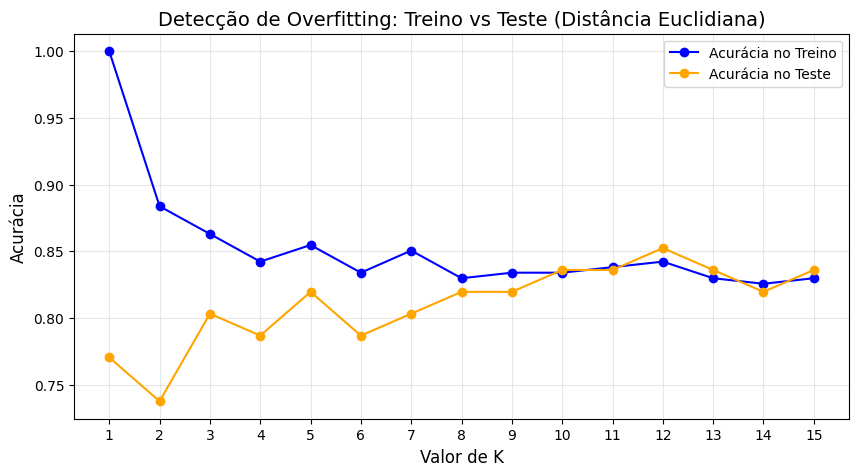

In [32]:
k_valores = range(1, 16)
acuracia_treino = []
acuracia_teste = []

for k in k_valores:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_treino, y_treino)
    
    # 1. Avaliando os dados de TREINO
    pred_treino = knn.predict(X_treino)
    acuracia_treino.append(accuracy_score(y_treino, pred_treino))
    
    # 2. Avaliando os dados de TESTE
    pred_teste = knn.predict(X_teste)
    acuracia_teste.append(accuracy_score(y_teste, pred_teste))

# Plotando o gráfico comparativo
plt.figure(figsize=(10, 5))
plt.plot(k_valores, acuracia_treino, marker='o', label='Acurácia no Treino', color='blue')
plt.plot(k_valores, acuracia_teste, marker='o', label='Acurácia no Teste', color='orange')

plt.title('Detecção de Overfitting: Treino vs Teste (Distância Euclidiana)', fontsize=14)
plt.xlabel('Valor de K', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(k_valores)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 4.3 Validação e Teste do Modelo Final

Denitivamente a melhor configuração para o algoritmo é utilizar a distância **Euclidean** com **K=12** (onde obteve ~85% de acurácia sem sofrer de *overfitting*).

A Matriz de Confusão permite visualizar detalhadamente os acertos e erros do modelo divididos pelas classes reais (Saudável vs. Doente) no conjunto de teste de 61 pacientes.

* **Acertos (Verdadeiros Positivos e Negativos):** O modelo identificou corretamente 29 pacientes doentes e 23 pacientes saudáveis.

* **Erros Críticos (Falsos Negativos):** Apenas 4 pacientes que estavam doentes foram classificados como saudáveis. Na medicina, esse é o erro que mais queremos evitar, pois o paciente ficaria sem tratamento.

* **Falsos Positivos:** 5 pacientes saudáveis foram classificados como doentes (um alerta falso, que seria descartado por exames posteriores).

A Curva ROC avalia a capacidade do modelo de separar corretamente as duas classes (doentes de saudáveis) variando sua margem de tolerância. A área debaixo dessa curva é chamada de **AUC**.

O modelo alcançou um **AUC de 0.87**. Em estatística, um valor de 0.5 representa um chute aleatório (como jogar uma moeda) e 1.0 representa a perfeição. Um AUC de 0.87 atesta um **excelente poder de discriminação clínica**, provando que o algoritmo tem alta certeza matemática ao separar os pacientes.

In [36]:
modelo_final = KNeighborsClassifier(n_neighbors=12, metric='euclidean')

modelo_final.fit(X_treino, y_treino)

acuracia_final = accuracy_score(y_teste, modelo_final.predict(X_teste))

print(f"O Modelo Definitivo foi treinado com sucesso!")
print(f"Acurácia final esperada para novos pacientes: {acuracia_final:.2%}")

O Modelo Definitivo foi treinado com sucesso!
Acurácia final esperada para novos pacientes: 85.25%


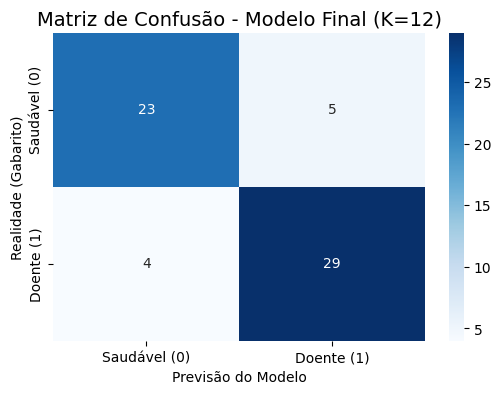

In [49]:
previsoes = modelo_final.predict(X_teste)

matriz = confusion_matrix(y_teste, previsoes)

plt.figure(figsize=(6, 4))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Saudável (0)', 'Doente (1)'], 
            yticklabels=['Saudável (0)', 'Doente (1)'])
plt.title('Matriz de Confusão - Modelo Final (K=12)', fontsize=14)
plt.ylabel('Realidade (Gabarito)')
plt.xlabel('Previsão do Modelo')
plt.show()

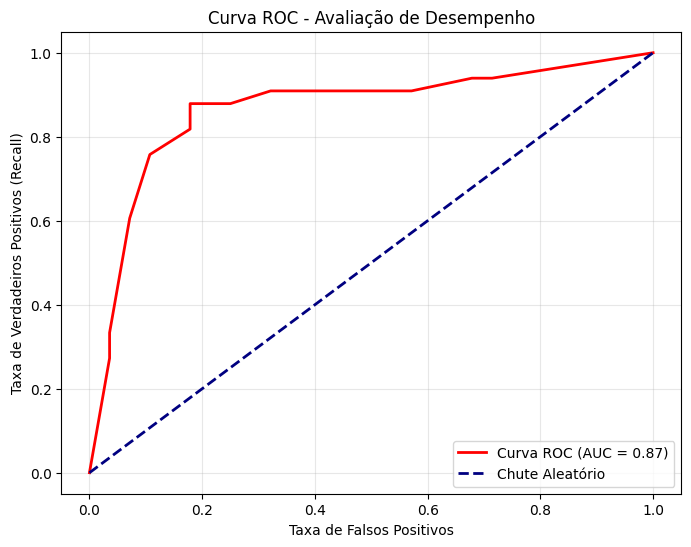

In [ ]:
probabilidades_doente = modelo_final.predict_proba(X_teste)[:, 1]

fpr, tpr, limites = roc_curve(y_teste, probabilidades_doente)
auc = roc_auc_score(y_teste, probabilidades_doente)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='red', lw=2, label=f'Curva ROC (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Chute Aleatório')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos (Recall)')
plt.title('Curva ROC - Avaliação de Desempenho')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()